# Phase 3 Project: Predicting H1N1 Vaccination Status


======================================
## 1. Business Understanding
======================================

#### *Objective:*
The primary goal is to *predict whether an individual received the H1N1 flu vaccine* based on their backgrounds, opinions, and health behaviors.

#### *Why It Matters:*
1. *Public Health Strategy:* Understanding factors that lead to vaccination helps officials design better outreach programs.
2. *Pandemic Preparedness:* Insights from the 2009 H1N1 pandemic can inform responses to future respiratory disease outbreaks.
3. *Resource Allocation:* Identifying demographic groups with low vaccination rates allows for targeted resource distribution.

#### *Key Stakeholders:*
1. *Public Health Officials (e.g., CDC):* For policy-making and communication strategies.
2. *Healthcare Providers:* To understand patient barriers to vaccination.
3. *Pharmaceutical Companies:* For vaccine distribution planning.

#### *Problem Description:*
Using the National 2009 H1N1 Flu Survey data, we aim to answer:
1. What behavioral factors (e.g., hand washing, mask wearing) correlate with vaccination?
2. How do opinions on vaccine effectiveness and risk influence the decision to get vaccinated?
3. Which demographic features are the strongest predictors of H1N1 vaccination status?

#### *Expected Outcome:*
A classification model that predicts vaccination status and identifies key drivers, providing actionable insights for public health campaigns.

==============================
## 2. Setup
==============================

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, plot_roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


==============================
## 3. Data Understanding
==============================

A vaccine for the H1N1 flu virus became publicly available in October 2009. In late 2009 and early 2010, the United States conducted the National 2009 H1N1 Flu Survey. This phone survey asked respondents whether they had received the H1N1 and seasonal flu vaccines, in conjunction with questions about themselves. These additional questions covered their social, economic, and demographic background, opinions on risks of illness and vaccine effectiveness, and behaviors towards mitigating transmission.

In [136]:
# Load datasets
features = pd.read_csv('training_set_features.csv')
labels = pd.read_csv('training_set_labels.csv')

# Merge features and labels
df = features.merge(labels, on='respondent_id')

print(df.shape)
df.head()

(26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

In [138]:
# Investigate the classes
print(df['h1n1_vaccine'].value_counts(normalize=True))

0    0.787546
1    0.212454
Name: h1n1_vaccine, dtype: float64


### Exploratory Data Analysis (EDA)
Exploring relationships between key features and the target variable.

In [139]:
def plot_vaccination_rate(df, col):
    rate = df.groupby(col)['h1n1_vaccine'].mean() * 100
    rate.plot(kind='bar')
    plt.title(f'Vaccination Rate by {col}')
    plt.ylabel('% Vaccinated')
    plt.show()

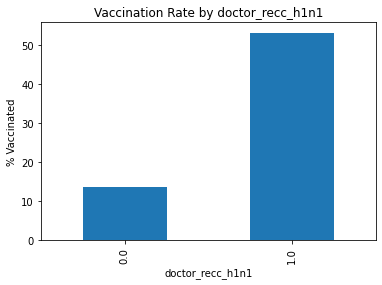

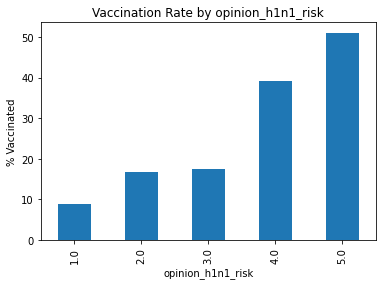

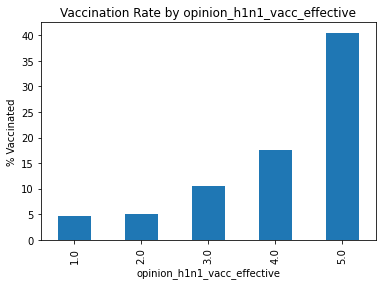

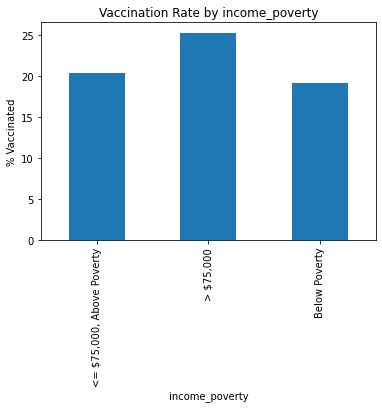

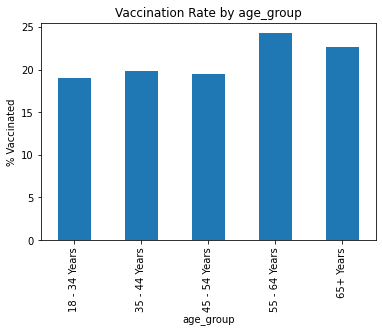

In [140]:
plot_vaccination_rate(df, 'doctor_recc_h1n1')
plot_vaccination_rate(df, 'opinion_h1n1_risk')
plot_vaccination_rate(df, 'opinion_h1n1_vacc_effective')
plot_vaccination_rate(df, 'income_poverty')
plot_vaccination_rate(df, 'age_group')

In [141]:
behavioral_cols = ['behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_avoidance']

for col in behavioral_cols:
    rate = df.groupby(col)['h1n1_vaccine'].mean() * 100
    print(f"Vaccination rate for {col}:")
    print(rate)
    print("-" * 30)

Vaccination rate for behavioral_face_mask:
behavioral_face_mask
0.0    20.453173
1.0    31.830527
Name: h1n1_vaccine, dtype: float64
------------------------------
Vaccination rate for behavioral_wash_hands:
behavioral_wash_hands
0.0    14.602151
1.0    22.657279
Name: h1n1_vaccine, dtype: float64
------------------------------
Vaccination rate for behavioral_avoidance:
behavioral_avoidance
0.0    18.113052
1.0    22.488038
Name: h1n1_vaccine, dtype: float64
------------------------------


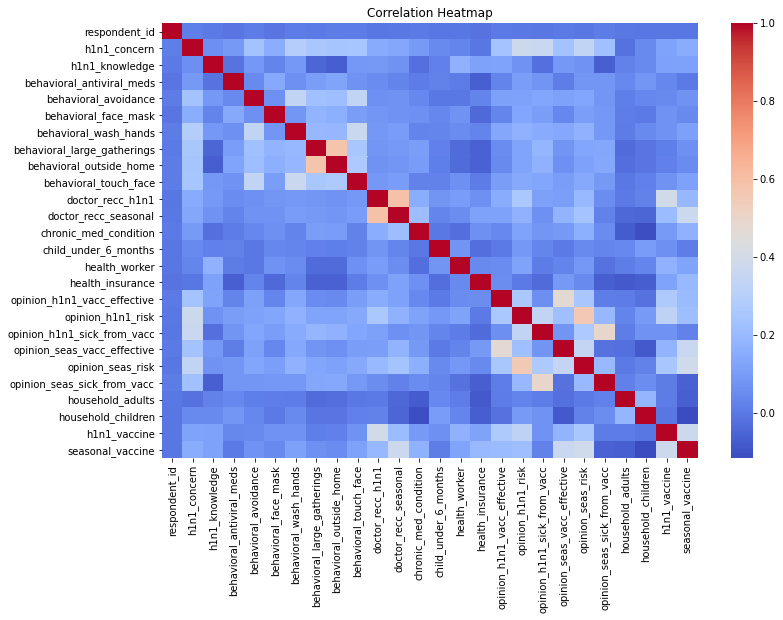

In [142]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(num_cols.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

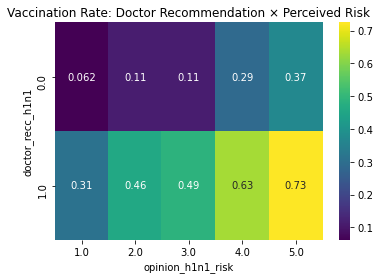

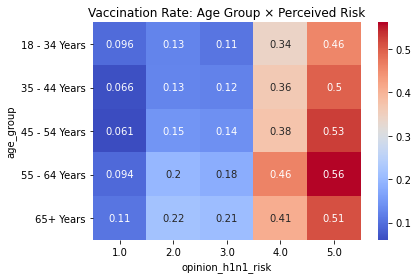

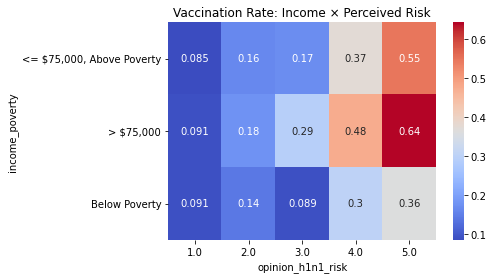

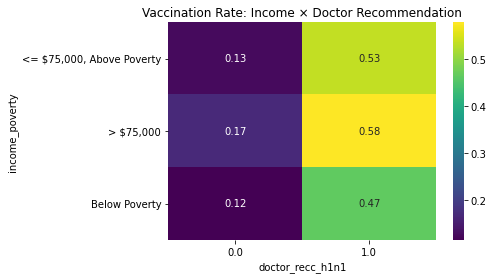

In [143]:
# Interaction between Doctor Recommendation & Perceived Risk
doc_cern = pd.crosstab(
    df['doctor_recc_h1n1'],
    df['opinion_h1n1_risk'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(doc_cern, annot=True, cmap='viridis')
plt.title("Vaccination Rate: Doctor Recommendation × Perceived Risk")
plt.show()


# Interaction between Age Group & Perceived Risk of H1N1
age_risk = pd.crosstab(
    df['age_group'],
    df['opinion_h1n1_risk'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(age_risk, annot=True, cmap='coolwarm')
plt.title("Vaccination Rate: Age Group × Perceived Risk")
plt.show()


# Interaction between Income & Perceived Risk of H1N1
income_risk = pd.crosstab(
    df['income_poverty'],
    df['opinion_h1n1_risk'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(income_risk, annot=True, cmap='coolwarm')
plt.title("Vaccination Rate: Income × Perceived Risk")
plt.show()


# Interaction between Income & Doctor Recommendation
income_doc = pd.crosstab(
    df['income_poverty'],
    df['doctor_recc_h1n1'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(income_doc, annot=True, cmap='viridis')
plt.title("Vaccination Rate: Income × Doctor Recommendation")
plt.show()

Vaccination rates among individuals who consider vaccines effective (5) are at 40% compared to those who don't (1 and 2) at 5%

Individuals are increasingly more likely to get vaccinated if they perceive themselves to be at higher risk of h1n1

High income individuals who perceive themselves to be at higher risk are more likely to vaccinate than below poverty individuals who also perceive themselves to be at high risk

Individuals who perceive themselves to be at low risk (1) are more likely to get vaccinated if they get doctor recommendations than individuals who perceive themselves to be at high risk (4) but do not get doctor recommendations.

These patterns observed in EDA are later confirmed by the predictive models, reinforcing the importance of perception and medical guidance in vaccination decisions

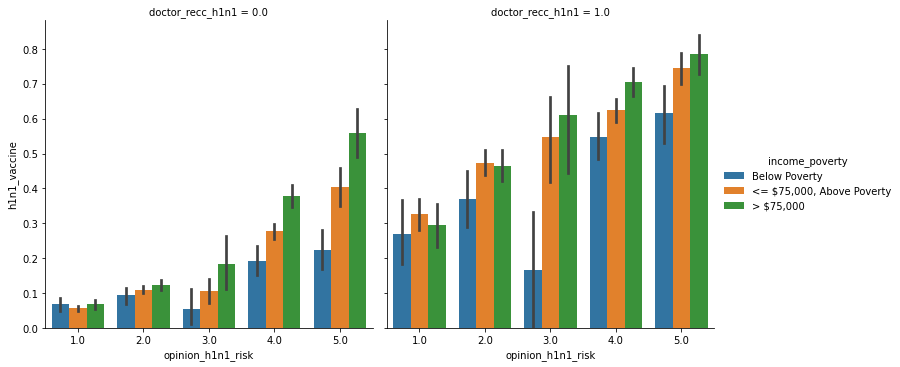

In [144]:
sns.catplot(
    data=df,
    x='opinion_h1n1_risk',
    y='h1n1_vaccine',
    hue='income_poverty',
    col='doctor_recc_h1n1',
    kind='bar'
)

==============================
## 4. Cleaning
==============================

In [145]:
def clean_data(df):
    df = df.copy()

    missing = df.isna().sum()
    threshold = 0.5 * len(df)
    cols_to_drop = missing[missing > threshold].index.tolist()

    cols_to_drop += ['respondent_id', 'seasonal_vaccine']

    df = df.drop(columns=cols_to_drop)

    return df

df_clean = clean_data(df)

In [146]:
# Check for duplicates
print(f"Number of duplicate rows: {df_clean.duplicated().sum()}")

Number of duplicate rows: 0


==============================
## 5. Preprocessing
==============================

In [147]:
X = df_clean.drop(columns='h1n1_vaccine')
y = df_clean['h1n1_vaccine']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
print(y_train.value_counts(normalize=True))

0    0.787316
1    0.212684
Name: h1n1_vaccine, dtype: float64


The imbalance is addressed using SMOTE, which performs oversampling by generating synthetic data for the minority class.

In [149]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

print("Categorical Columns:", cat_cols)
print("Numeric Columns:", num_cols)

Categorical Columns: Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry'],
      dtype='object')
Numeric Columns: Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults',
       'household_children'],
      dtype='object')


In [150]:
# Preprocessing pipeline

def build_preprocessor(X):
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer([
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ])

    return preprocessor

preprocessor = build_preprocessor(X)

==============================
## 6. Modeling
==============================

### 6.1 Logistic Regression (base)

In [151]:
# Define the SMOTE Logistic Regression Pipeline
logreg_smote_model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# Fit the model
logreg_smote_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'emp...
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effectiv

In [152]:
# Predict and Evaluate
y_pred_log = logreg_smote_model.predict(X_test)
# Probability of the positive class (Vaccinated)
y_prob_log = logreg_smote_model.predict_proba(X_test)[:, 1]

### 6.2 Logistic Regression (Tuned)

In [153]:
param_grid_log = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}


grid_log = GridSearchCV(logreg_smote_model,param_grid_log,cv=5,scoring='roc_auc',n_jobs=-1)

grid_log.fit(X_train, y_train)

best_log_model = grid_log.best_estimator_


In [154]:
# GridSearchCV with 5-fold cross-validation was used to tune hyperparameters
# To ensure that model performance is evaluated across multiple data splits, reducing overfitting and improving generalizability

In [155]:
# The top predictors

preprocessor = best_log_model.named_steps['preprocessor']
cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names(
    preprocessor.transformers_[0][2]
)

num_features = preprocessor.transformers_[1][2]


# Combine feature names
feature_names = list(cat_features) + list(num_features)

coefficients = best_log_model.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

feature_importance['abs_coef'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

feature_importance.head(10)

,feature,coefficient,abs_coef
43,employment_industry_haxffmxo,2.584851,2.584851
68,doctor_recc_h1n1,0.897522,0.897522
74,opinion_h1n1_vacc_effective,0.660794,0.660794
38,employment_industry_arjwrbjb,0.592707,0.592707
75,opinion_h1n1_risk,0.497890,0.497890
42,employment_industry_fcxhlnwr,0.339711,0.339711
50,employment_industry_pxcmvdjn,-0.337935,0.337935
9,race_Black,-0.332414,0.332414
69,doctor_recc_seasonal,-0.320761,0.320761
2,age_group_45 - 54 Years,-0.303168,0.303168


Several encoded categories from employment-related variables appear among the top predictors. While individual category labels are not directly interpretable eg. 'haxffmxo' has a very strong positive effect (perhaps the code represents a high exposure environment like healthcare), this suggests that employment characteristics play a role in vaccination behaviour.

Variables related to doctor recommendation (0.898), belief in vaccine effectiveness (0.661) and perceived risk (0.498) are among the most influential predictors of vaccination status.

Both positive and negative coefficients are observed among the top features, suggesting that while certain factors encourage vaccination, others may act as barriers.

demographic factors such as age and race also contribute to prediction, with ages 45-54 and 'black' reducing likelihood of H1N1 vaccination.

In [156]:
y_prob_tuned_log = best_log_model.predict_proba(X_test)[:,1]
y_pred_tuned_log = best_log_model.predict(X_test)

### 6.3 Decision Tree (base)

In [157]:
dt_smote_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Fit the model
dt_smote_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'emp...
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effectiv

In [158]:

y_pred_dt = dt_smote_model.predict(X_test)
y_prob_dt = dt_smote_model.predict_proba(X_test)[:, 1]

### 6.4 Decision Tree (Tuned)

In [ ]:
param_grid = {
    'classifier__max_depth': [3, 5, 10],
    'classifier__min_samples_leaf': [1, 5, 10]}


grid_search = GridSearchCV(dt_smote_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_smote_dt = grid_search.best_estimator_

# print(f"Best Parameters: {grid_search.best_params_}")

In [ ]:
y_prob_tuned_tree = best_smote_dt.predict_proba(X_test)[:, 1]
y_pred_tuned_tree = best_smote_dt.predict(X_test)

==============================
## 7. Evaluation
==============================

### 7.1 Confusion matrices

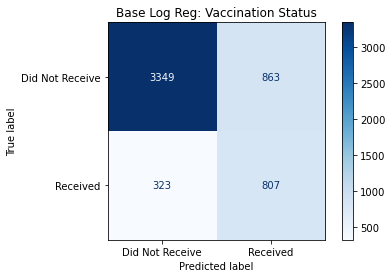

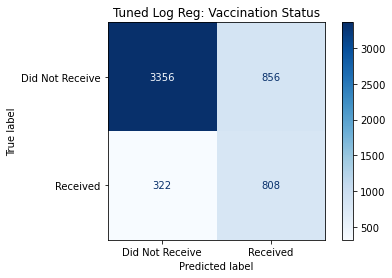

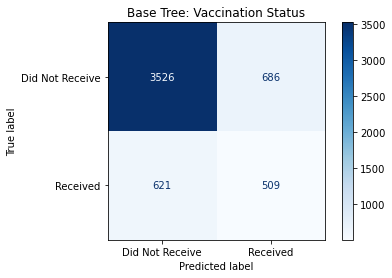

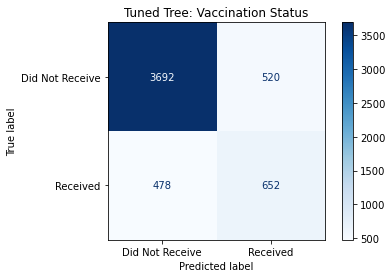

In [ ]:
cnf_matrix = confusion_matrix(y_test, y_pred_log)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Base Log Reg: Vaccination Status')
plt.show()


cnf_matrix = confusion_matrix(y_test, y_pred_tuned_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Tuned Log Reg: Vaccination Status')
plt.show()


cnf_matrix = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Base Tree: Vaccination Status')
plt.show()


cnf_matrix = confusion_matrix(y_test, y_pred_tuned_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Tuned Tree: Vaccination Status')
plt.show()

### 7.2 Logistic Regression metrics

In [ ]:
print("Base Logistic Regression Model:")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))
print("-" * 55)
print("\n")

print("Tuned Logistic Regression Model:")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned_log))
print(classification_report(y_test, y_pred_tuned_log))

Base Logistic Regression Model:
ROC-AUC: 0.828595290320954
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.48      0.71      0.58      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342

-------------------------------------------------------


Tuned Logistic Regression Model:
ROC-AUC: 0.8292394675138037
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.49      0.72      0.58      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.71      5342
weighted avg       0.82      0.78      0.79      5342



Hyperparameter tuning resulted in minimal performance improvement, suggesting that the baseline Logistic Regression model was already well-suited to the structure of the data.


### 7.3 Decision Tree metrics

In [ ]:
print("Base Decision Tree Model:")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(classification_report(y_test, y_pred_dt))
print("-" * 55)
print("\n")

print("Tuned Decision Tree Model:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned_tree):.4f}")
print(classification_report(y_test, y_pred_tuned_tree))

Base Decision Tree Model:
ROC-AUC: 0.6437872408373884
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4212
           1       0.43      0.45      0.44      1130

    accuracy                           0.76      5342
   macro avg       0.64      0.64      0.64      5342
weighted avg       0.76      0.76      0.76      5342

-------------------------------------------------------


Tuned Decision Tree Model:
ROC-AUC: 0.8063
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4212
           1       0.56      0.58      0.57      1130

    accuracy                           0.81      5342
   macro avg       0.72      0.73      0.72      5342
weighted avg       0.82      0.81      0.81      5342



### 7.4 ROC Curves

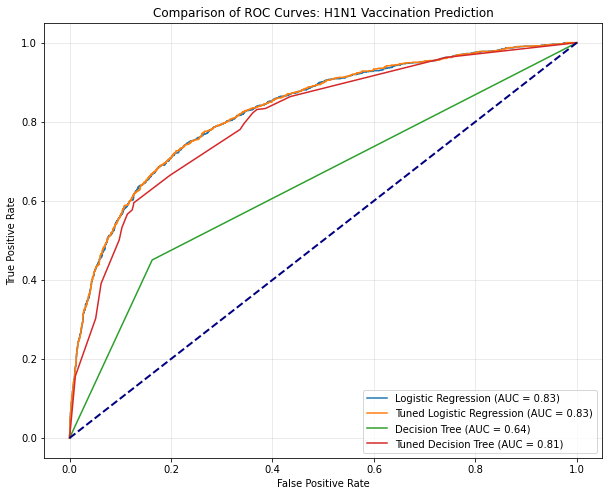

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

plot_roc_curve(logreg_smote_model, X_test, y_test, ax=ax, name='Logistic Regression')

plot_roc_curve(best_log_model, X_test, y_test, ax=ax, name='Tuned Logistic Regression')

plot_roc_curve(dt_smote_model, X_test, y_test, ax=ax, name='Decision Tree')

plot_roc_curve(best_smote_dt, X_test, y_test, ax=ax, name='Tuned Decision Tree')

# Diagonal line for reference
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.title('Comparison of ROC Curves: H1N1 Vaccination Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
models = {
    "Base Logistic Regression": (y_test, y_pred_log, y_prob_log),
    "Tuned Logistic Regression": (y_test, y_pred_tuned_log, y_prob_tuned_log),
    "Base Decision Tree": (y_test, y_pred_dt, y_prob_dt),
    "Tuned Decision Tree": (y_test, y_pred_tuned_tree, y_prob_tuned_tree)
}


results = []

for name, (y_true, y_pred, y_prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    })


results_df = pd.DataFrame(results)

results_df = results_df.round(3)

results_df

,Model,Accuracy,ROC-AUC,Precision,Recall,F1-Score
0,Base Logistic Regression,0.778,0.829,0.483,0.714,0.576
1,Tuned Logistic Regression,0.779,0.829,0.486,0.715,0.578
2,Base Decision Tree,0.755,0.644,0.426,0.450,0.438
3,Tuned Decision Tree,0.813,0.806,0.556,0.577,0.566


Although the tuned Decision Tree achieved the highest accuracy (0.81), Logistic Regression outperformed all models in terms of ROC-AUC (0.828).

Therefore Logistic Regression is the better model due to its superior overall predictive performance.

==============================
## 8. Conclusion
==============================

The Logistic Regression model was selected as the final model due to its strong ROC-AUC performance (~0.83) and stability.

ROC-AUC was the primary metric because it evaluates model performance across all classification thresholds and is well-suited for imbalanced datasets.

==============================
## 9. Key Findings
==============================
- Doctor recommendation is the strongest driver of vaccination, highlighting the importance of trusted medical advice
- Belief in vaccine effectiveness significantly increases uptake
- Individuals with higher perceived risk of infection are more likely to vaccinate
- Certain employment characteristics appear to influence vaccination behavior, although the effects are less directly interpretable.
- Demographic factors like age and race have measurable but smaller effects (eg., ages 45-54 and Black respondents are slightly less likely to vaccinate)

==============================
## 10. Recommendations
==============================

**Leverage healthcare providers**
- Encourage doctors to actively recommend vaccines

**Increase risk awareness campaigns**
- Public campaigns should outline the likelihood (and severity) of infection

**Promote Vaccine Effectiveness**
- Address misinformation, communicate the successes of vaccines in general and reinforce the public's confidence in them

**Consider targeted outreach for certain demographic groups**
- Engage communities to understand barriers, and address them, including whatever systemic issues that may be underlying the effects